# Домашнее задание №3 (Вариант ResNext-50)
## Выполнил Тараканов Борис (ст.б. 1032259220), ЗФИмд-01-25

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')

Используемое устройство: cuda


In [6]:
class ResNeXtBottleneck(nn.Module):
    expansion = 2

    def __init__(self, in_channels, out_channels, stride=1, cardinality=32, base_width=4):
        
        super().__init__()
        # Ширина bottleneck внутри группы
        group_width = cardinality * base_width 

        # --- Split-Transform-Merge ---
        # 1x1 свёртка, сжимающая вход до group_width каналов
        self.conv1 = nn.Conv2d(in_channels, group_width, kernel_size=1, bias=False)
        self.bn1   = nn.BatchNorm2d(group_width)

        # 3x3 групповая свёртка: каждая группа обрабатывает свои base_width каналов
        # Параметр groups=cardinality делит каналы на cardinality независимых групп
        self.conv2 = nn.Conv2d(group_width, group_width, kernel_size=3, stride=stride,
                               padding=1, groups=cardinality, bias=False)
        self.bn2   = nn.BatchNorm2d(group_width)

        # 1x1 свёртка, расширяющая до out_channels*expansion
        self.conv3 = nn.Conv2d(group_width, out_channels * self.expansion,
                               kernel_size=1, bias=False)
        self.bn3   = nn.BatchNorm2d(out_channels * self.expansion)

        # Активация
        self.relu = nn.ReLU(inplace=True)

        # Residual-связь (если размерности не совпадают)
        self.downsample = None
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)   
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity         
        out = self.relu(out)

        return out

In [7]:
class ResNeXt50(nn.Module):
    def __init__(self, num_classes=10, cardinality=32, base_width=4):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.relu  = nn.ReLU(inplace=True)

        # 4 стадии ResNeXt
        self.layer1 = self._make_layer(64,  3, stride=1, cardinality=cardinality, base_width=base_width)
        self.layer2 = self._make_layer(128, 4, stride=2, cardinality=cardinality, base_width=base_width)
        self.layer3 = self._make_layer(256, 6, stride=2, cardinality=cardinality, base_width=base_width)
        self.layer4 = self._make_layer(512, 3, stride=2, cardinality=cardinality, base_width=base_width)

        # Классификатор
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512 * ResNeXtBottleneck.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, out_channels, blocks, stride, cardinality, base_width):
        layers = []
        layers.append(ResNeXtBottleneck(self.in_channels, out_channels, stride,
                                        cardinality, base_width))
        self.in_channels = out_channels * ResNeXtBottleneck.expansion
        for _ in range(1, blocks):
            layers.append(ResNeXtBottleneck(self.in_channels, out_channels, 1,
                                            cardinality, base_width))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [8]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('самолёт', 'автомобиль', 'птица', 'кот', 'олень',
           'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик')

Files already downloaded and verified
Files already downloaded and verified


In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc  = 100. * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    epoch_loss = running_loss / total
    epoch_acc  = 100. * correct / total
    return epoch_loss, epoch_acc

In [10]:
model = ResNeXt50(num_classes=10, cardinality=32, base_width=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

print(f'Параметров в модели: {sum(p.numel() for p in model.parameters()):,}')

Параметров в модели: 2,619,722


In [11]:
num_epochs = 30  
train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc   = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f'Epoch {epoch+1:3d}/{num_epochs} '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%')

Epoch   1/30 Train Loss: 2.3441 | Train Acc: 24.45% | Test Loss: 1.7351 | Test Acc: 36.34%
Epoch   2/30 Train Loss: 1.6672 | Train Acc: 37.53% | Test Loss: 1.5695 | Test Acc: 41.89%
Epoch   3/30 Train Loss: 1.5016 | Train Acc: 44.86% | Test Loss: 1.4538 | Test Acc: 46.84%
Epoch   4/30 Train Loss: 1.3756 | Train Acc: 49.83% | Test Loss: 1.2989 | Test Acc: 53.04%
Epoch   5/30 Train Loss: 1.2462 | Train Acc: 55.40% | Test Loss: 1.3178 | Test Acc: 54.38%
Epoch   6/30 Train Loss: 1.1106 | Train Acc: 60.54% | Test Loss: 1.2031 | Test Acc: 58.57%
Epoch   7/30 Train Loss: 0.9741 | Train Acc: 65.41% | Test Loss: 1.0482 | Test Acc: 63.55%
Epoch   8/30 Train Loss: 0.8523 | Train Acc: 70.10% | Test Loss: 0.8802 | Test Acc: 69.87%
Epoch   9/30 Train Loss: 0.7664 | Train Acc: 73.18% | Test Loss: 0.8504 | Test Acc: 71.12%
Epoch  10/30 Train Loss: 0.7003 | Train Acc: 75.86% | Test Loss: 0.9834 | Test Acc: 67.97%
Epoch  11/30 Train Loss: 0.6509 | Train Acc: 77.20% | Test Loss: 0.7739 | Test Acc: 74.12%

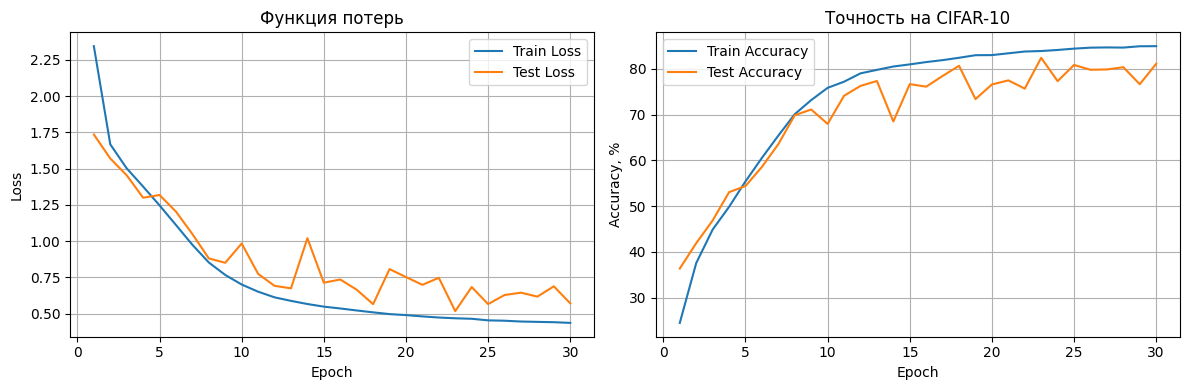

In [12]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Функция потерь')

plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), train_accs, label='Train Accuracy')
plt.plot(range(1, num_epochs+1), test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy, %')
plt.legend()
plt.grid(True)
plt.title('Точность на CIFAR-10')

plt.tight_layout()
plt.show()

Входная форма: torch.Size([1, 8, 8, 8])
Выходная форма: torch.Size([1, 8, 8, 8])
Карта признаков после групповой свёртки: каждая группа преобразована независимо, затем объединена.


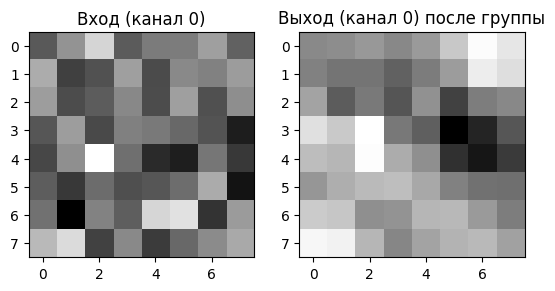

In [13]:
# Демонстрация: групповая свёртка 3x3 с 4 группами
demo_input = torch.randn(1, 8, 8, 8)          # batch=1, 8 каналов, 8x8
group_conv = nn.Conv2d(8, 8, 3, padding=1, groups=4, bias=False)

with torch.no_grad():
    # Каждая группа обрабатывает 2 канала
    k = group_conv.weight
    k.zero_()
    k[0:2] = 1.0    # группа 1 – простое размытие
    k[2:4] = -1.0   # группа 2 – инвертирование
    k[4:6] = 0.5    # группа 3 – подавление
    k[6:8] = 2.0    # группа 4 – усиление

out = group_conv(demo_input)
print(f'Входная форма: {demo_input.shape}')
print(f'Выходная форма: {out.shape}')
print('Карта признаков после групповой свёртки: каждая группа преобразована независимо, затем объединена.')

# Визуализируем один пример канала входа и выхода
fig, ax = plt.subplots(1,2)
ax[0].imshow(demo_input[0,0].detach().numpy(), cmap='gray')
ax[0].set_title('Вход (канал 0)')
ax[1].imshow(out[0,0].detach().numpy(), cmap='gray')
ax[1].set_title('Выход (канал 0) после группы')
plt.show()